<a href="https://colab.research.google.com/github/envirodatascience/final-project-pargoal-kei-team/blob/main/final_project_pargoal_kei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from plotnine import *
import plotnine
import numpy as np

import geopandas as gpd
from shapely.geometry import Polygon

In [3]:
# Upload Heat Pump Data - use this one 4/26
url = "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/refs/heads/main/WS%20Map_all.csv"
hp_df = pd.read_csv(url)  # Try different encoding
hp_df.head()
hp_df.value_counts()

Legal Town     Heat Pump Type                    RNC      Sector  Source Program Name  Utility     Year  LEGAL TOWN     Program   Source Program              Project Measure: Measure Total Quantity
West Hartford  Air Source Heat Pump, Ducted      Not RNC  RES     RES HVAC             Eversource  2023  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          243
Stamford       Air Source Heat Pump, Ducted      Not RNC  RES     RES HVAC             Eversource  2023  STAMFORD       Tracksys  Energy Optimization Rebate  1                                          243
West Hartford  Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          224
                                                                                                   2022  WEST HARTFORD  Tracksys  Energy Optimization Rebate  1                                          221
Guilford       Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  GUILFORD       Tracksys  Energy Optimization Rebate  1                                          207
                                                                                                                                                                                                        ... 
Ansonia        Air Source Heat Pump, Mini Split  Not RNC  C&I     ECB                  UI          2023  ANSONIA        EXP       EXP                         2                                            1
                                                                                                                                                              3                                            1
                                                                                                                        MID       MID                         1                                            1
Woodbury       Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             Eversource  2021  WOODBURY       Tracksys  Energy Optimization Rebate  2                                            1
Ansonia        Air Source Heat Pump, Mini Split  Not RNC  RES     RES HVAC             UI          2020  ANSONIA        CTDSHP    CTDSHP                      1                                            1
Name: count, Length: 2810, dtype: int64

# Understanding Heat Pump Data

In [4]:
hp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54814 entries, 0 to 54813
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Legal Town                               54814 non-null  object
 1   Heat Pump Type                           54814 non-null  object
 2   RNC                                      54814 non-null  object
 3   Sector                                   54814 non-null  object
 4   Source Program Name                      41362 non-null  object
 5   Utility                                  54814 non-null  object
 6   Year                                     54814 non-null  int64 
 7   LEGAL TOWN                               54814 non-null  object
 8   Program                                  54814 non-null  object
 9   Source Program                           41362 non-null  object
 10  Project Measure: Measure Total Quantity  54814 non-null  i

In [5]:
hp_df.shape

(54814, 11)

In [6]:
hp_df['Heat Pump Type'].value_counts()

,count
Heat Pump Type,
"Air Source Heat Pump, Mini Split",40567
"Air Source Heat Pump, Ducted",13354
Ground Source Heat Pump,893


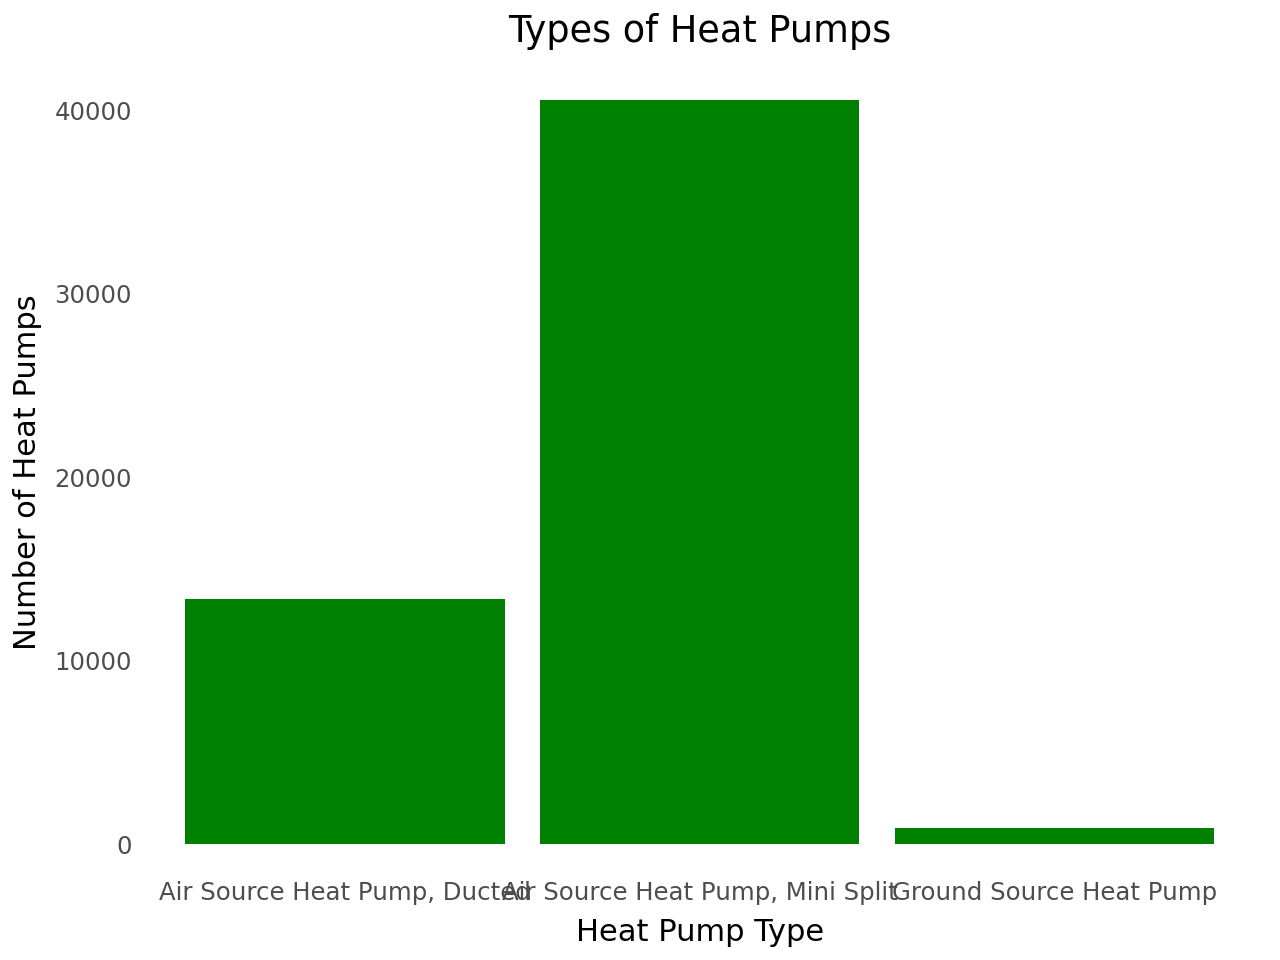

In [7]:
# Plotting by heat pump type
from plotnine import ggplot, aes, geom_bar, labs

plot = (
    ggplot(hp_df, aes(x='Heat Pump Type')) +
    geom_bar(fill="green") +   # <-- set the fill color directly here
    labs(title='Types of Heat Pumps', x='Heat Pump Type', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot


In [8]:
# Legal town is all capitizaled so need to change it to lower case
#hp_df[""]
hp_df.Year.value_counts()

,count
Year,
2023,18920
2022,11342
2021,9677
2020,5163
2019,4366
2018,3108
2017,2238


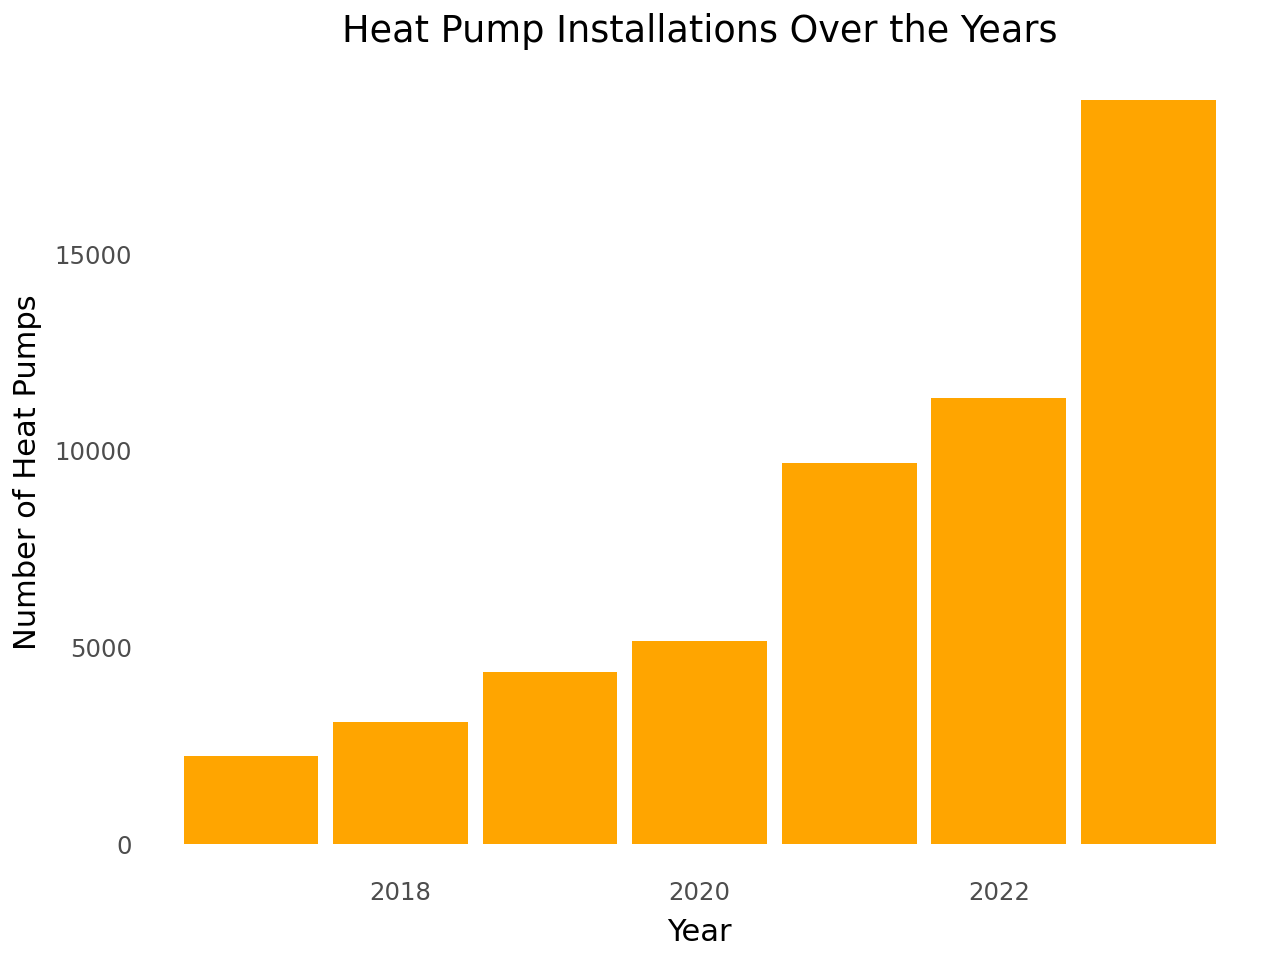

In [9]:
# Plotting by Years
plot = (
    ggplot(hp_df, aes(x='Year')) +
    geom_bar(fill="orange") +
    labs(title='Heat Pump Installations Over the Years', x='Year', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot

In [10]:
hp_df.Utility.value_counts()

,count
Utility,
Eversource,48378
UI,6436


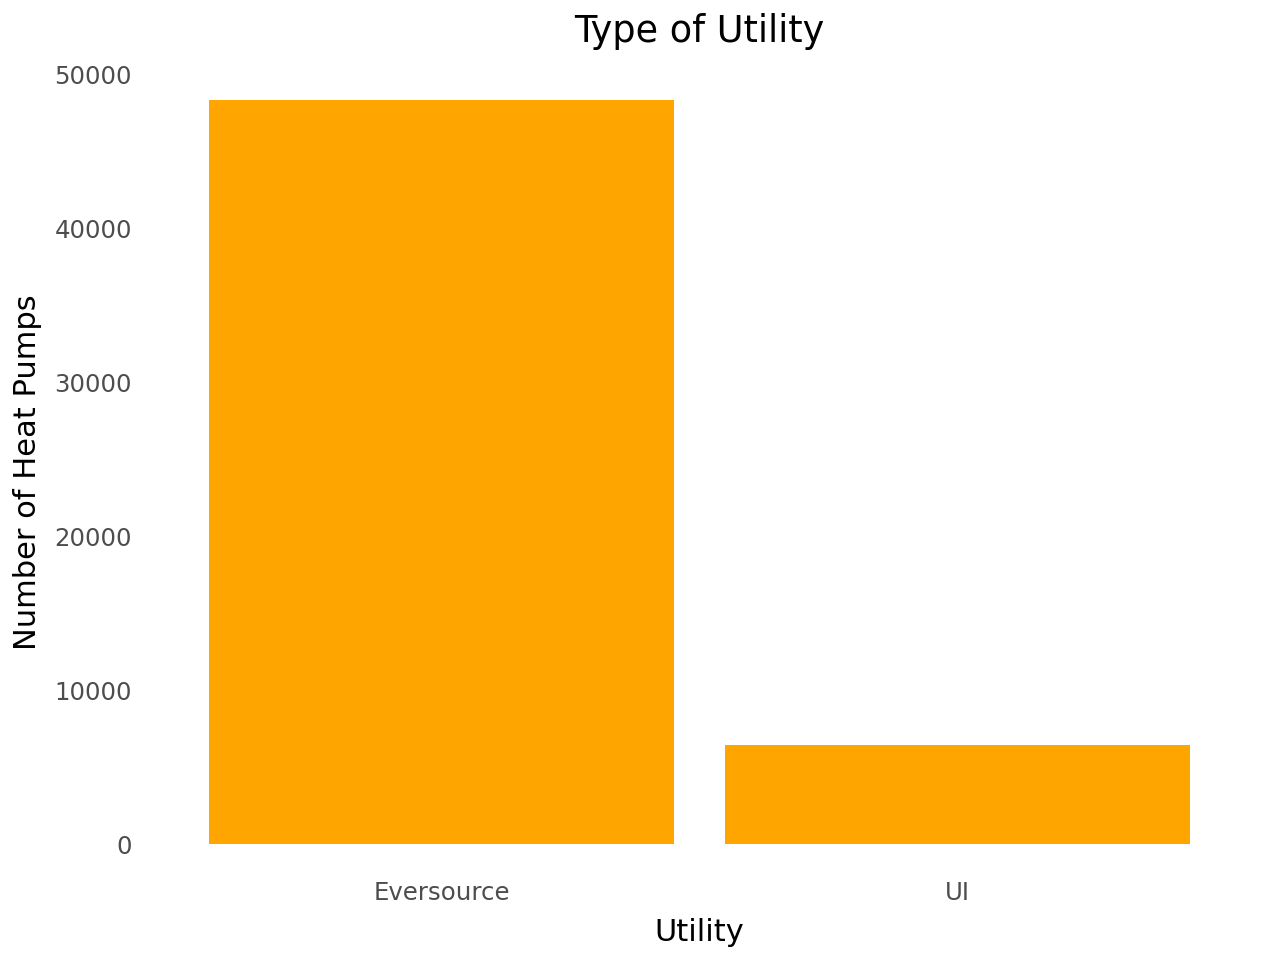

In [11]:
# Plotting by utility
plot = (
    ggplot(hp_df, aes(x='Utility')) +
    geom_bar(fill="orange") +
    labs(title='Type of Utility', x='Utility', y='Number of Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)
plot

In [13]:
# Aggregating the years and heat pump type

# Group by 'Legal Town' and sum the 'Project Measure: Measure Total Quantity'
combined_hp = hp_df.groupby('Legal Town')['Project Measure: Measure Total Quantity'].sum().reset_index()

# Rename the column if you want
combined_hp = combined_hp.rename(columns={'Project Measure: Measure Total Quantity': 'Total Heat Pumps'})
combined_hp = combined_hp.rename(columns={'Legal Town': 'TOWN'})


# View result
combined_hp.head()


,TOWN,Total Heat Pumps
0,Andover,95
1,Ansonia,115
2,Ashford,192
3,Avon,445
4,Barkhamsted,103


In [74]:
# check for NAs
combined_hp.isna().sum()

,0
TOWN,0
Total Heat Pumps,0


In [14]:
# Group by Legal Town and aggregate Utility into a combined string
combined_utilities = hp_df.groupby('Legal Town')['Utility'].unique().reset_index()
combined_utilities['Utility'] = combined_utilities['Utility'].apply(lambda x: ', '.join(x))

print(combined_utilities)
combined_utilities

        Legal Town     Utility
0          Andover  Eversource
1          Ansonia          UI
2          Ashford  Eversource
3             Avon  Eversource
4      Barkhamsted  Eversource
..             ...         ...
161  Windsor Locks  Eversource
162        Wolcott  Eversource
163     Woodbridge          UI
164       Woodbury  Eversource
165      Woodstock  Eversource

[166 rows x 2 columns]


,Legal Town,Utility
0,Andover,Eversource
1,Ansonia,UI
2,Ashford,Eversource
3,Avon,Eversource
4,Barkhamsted,Eversource
...,...,...
161,Windsor Locks,Eversource
162,Wolcott,Eversource
163,Woodbridge,UI
164,Woodbury,Eversource


In [79]:
# number of Legal Towns
combined_hp['TOWN'].nunique()

166

In [52]:
# Uploading Demographic Data (2023)
url = "https://raw.githubusercontent.com/envirodatascience/final-project-pargoal-kei-team/refs/heads/main/CT_demoU.csv"
demo_df = pd.read_csv(url)
demo_df.head()

,TOWN,Median Age,Median Home Value,Unemployment Rate,Per Income Capita,Tenure_Owner_Occupied(%),Tenure_Renter_Occupied(%),Housing Units,TOWN_NO,COUNTY,...,60_to_64_Years,18_to_24_Years,65_and_Over_Years,Total_Households,Median_Household_Income,SNAP_Recipients,Utility_gas,Bottled_tank_or_LP_gas,Electricity,Fuel_oil_kerosene_etc.
0,Andover,47.9,297400,4.7,44803,88.40,11.60,1275.0,1.0,Tolland,...,9.6,9.5,17.7,1216.0,99449.0,2.88,1.4,7.9,5.1,74.6
1,Ansonia,42.4,217800,9.6,30285,59.42,40.58,8867.0,2.0,New Haven,...,8.4,6.5,18.4,7806.0,53709.0,15.60,48.6,1.5,7.9,40.6
2,Ashford,37.8,271700,4.9,46602,73.68,26.32,2033.0,3.0,Windham,...,7.4,7.0,14.2,1774.0,84909.0,8.23,1.1,2.7,16.6,62.6
3,Avon,45.2,371900,4.1,74617,83.27,16.73,8042.0,4.0,Hartford,...,7.6,5.0,20.9,6977.0,123077.0,2.85,43.1,4.5,8.8,42.5
4,Barkhamsted,48.3,262900,5.0,43558,92.66,7.34,1473.0,5.0,Litchfield,...,5.9,6.0,24.0,1336.0,103500.0,2.10,0.7,2.8,7.4,80.7


In [121]:
# subset to just Town, Median Home Value, and Tenure_Owner_Occupied(%), and Tenure_Renter_Occupied(%)
demo_df = demo_df[['TOWN', 'Median_Household_Income', 'Tenure_Owner_Occupied(%)']]
demo_df.head()

,TOWN,Median_Household_Income,Tenure_Owner_Occupied(%)
0,Andover,99449.0,88.40
1,Ansonia,53709.0,59.42
2,Ashford,84909.0,73.68
3,Avon,123077.0,83.27
4,Barkhamsted,103500.0,92.66


In [122]:
# how many towns in demo_df
demo_df['TOWN'].nunique()

142

In [123]:
# check for NAs
demo_df.isna().sum()

,0
TOWN,0
Median_Household_Income,0
Tenure_Owner_Occupied(%),0


In [124]:
# remove NAs
demo_df = demo_df.dropna()

In [125]:
demo_df.isna().shape
# 142 towns left

(142, 3)

# Joining both Demographic Data and Heat Pump Data

In [126]:
joined_df = pd.merge(combined_hp, demo_df, on='TOWN', how='right')
joined_df.head()

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%)
0,Andover,95.0,99449.0,88.40
1,Ansonia,115.0,53709.0,59.42
2,Ashford,192.0,84909.0,73.68
3,Avon,445.0,123077.0,83.27
4,Barkhamsted,103.0,103500.0,92.66


In [127]:
joined_df.shape

(142, 4)

In [128]:
# remove all NAs
joined_df = joined_df.dropna()

In [129]:
joined_df.shape
# end up with 139 towns left that have both income, renters, and

(139, 4)

In [136]:
# create new column for above or below national average of home ownership
joined_df['Above_National_Average'] = joined_df['Tenure_Owner_Occupied(%)'] > 66
joined_df.head()

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average
0,Andover,95.0,99449.0,88.40,True
1,Ansonia,115.0,53709.0,59.42,False
2,Ashford,192.0,84909.0,73.68,True
3,Avon,445.0,123077.0,83.27,True
4,Barkhamsted,103.0,103500.0,92.66,True


# Analysis

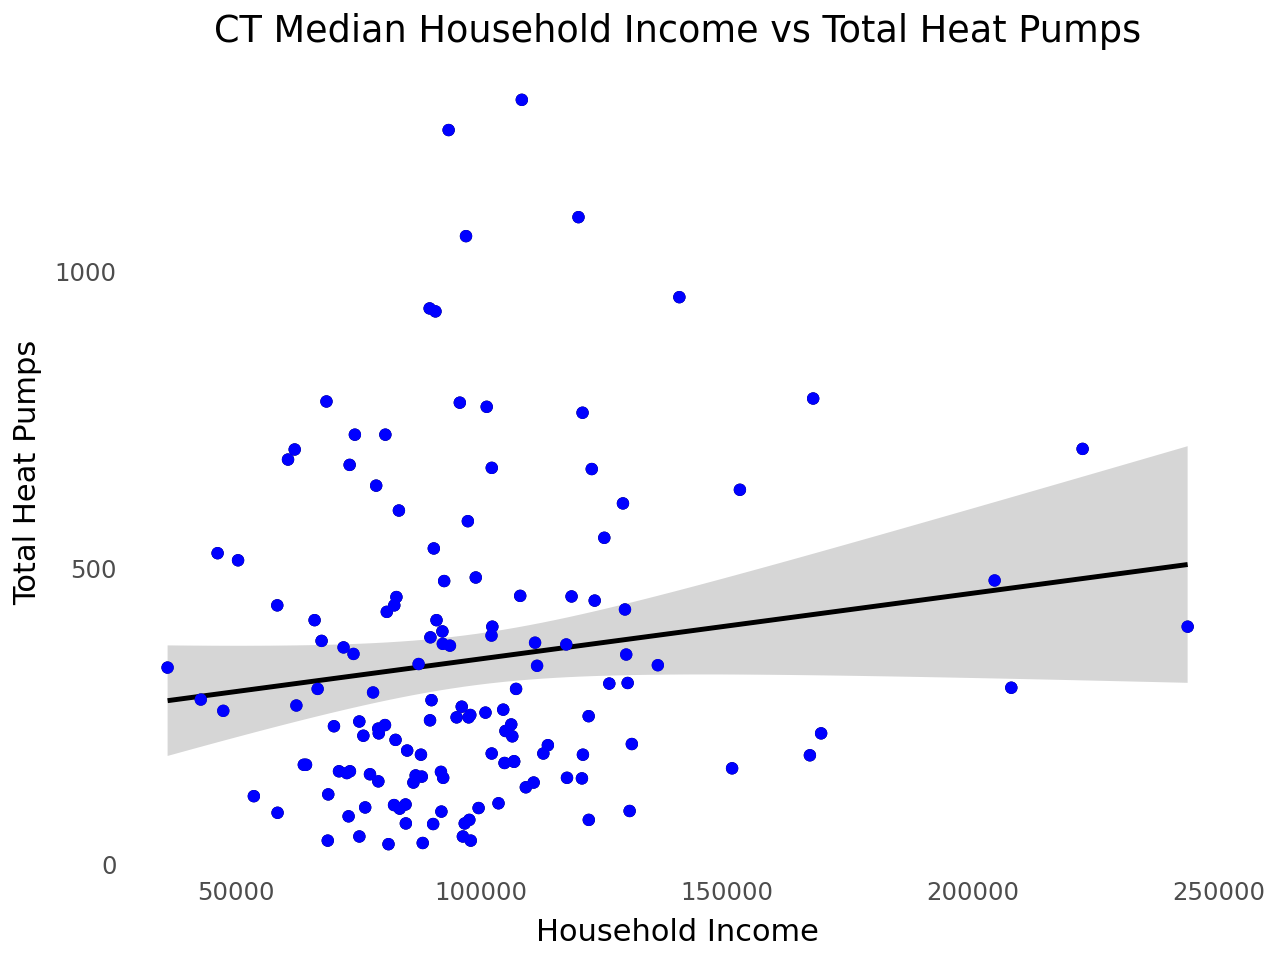

In [110]:
# create plot comparing household income and total heat pumps
(
    ggplot(joined_df, aes(x='Median_Household_Income', y='Total Heat Pumps')) +
    geom_point() +
    geom_smooth(method='lm') +
    theme_minimal() +
    geom_point(color="blue") +
    labs(title='CT Median Household Income vs Total Heat Pumps', x='Household Income', y='Total Heat Pumps') +
    theme_minimal() +  # white background
    theme(
        panel_grid_major=element_blank(),  # remove major gridlines
        panel_grid_minor=element_blank(),  # remove minor gridlines
    )
)

In [112]:
# do linear regression test to see correlation
import statsmodels.api as sm

# define model
model = sm.OLS(joined_df['Total Heat Pumps'], joined_df['Median_Household_Income'])

# fit model
results = model.fit()

# print results
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:       Total Heat Pumps   R-squared (uncentered):                   0.619
Model:                            OLS   Adj. R-squared (uncentered):              0.616
Method:                 Least Squares   F-statistic:                              223.7
Date:                Sat, 26 Apr 2025   Prob (F-statistic):                    1.14e-30
Time:                        22:42:44   Log-Likelihood:                         -973.25
No. Observations:                 139   AIC:                                      1948.
Df Residuals:                     138   BIC:                                      1951.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [139]:
# second analysis - T-test
import scipy.stats as stats

stats.ttest_ind(joined_df['Total Heat Pumps'][joined_df['Above_National_Average'] == True],
                joined_df['Total Heat Pumps'][joined_df['Above_National_Average'] == False])

TtestResult(statistic=np.float64(-1.9130508408116251), pvalue=np.float64(0.05782804761765743), df=np.float64(137.0))

## Uploading Spatial Data - CT Shapefile

In [140]:
# This works
!wget -O tl_2020_09_place20.zip "https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_09_place.zip"


--2025-04-26 23:05:16--  https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_09_place.zip
Resolving www2.census.gov (www2.census.gov)... 172.65.90.25, 172.65.90.26, 172.65.90.24, ...
Connecting to www2.census.gov (www2.census.gov)|172.65.90.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 867378 (847K) [application/zip]
Saving to: ‘tl_2020_09_place20.zip’

tl_2020_09_place20. 100%[===================>] 847.05K  1.04MB/s    in 0.8s    

2025-04-26 23:05:19 (1.04 MB/s) - ‘tl_2020_09_place20.zip’ saved [867378/867378]



In [152]:
# unzip
!unzip tl_2020_09_place20.zip

Archive:  tl_2020_09_place20.zip
replace tl_2020_09_place.cpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [142]:
shape = 'tl_2020_09_place.shp'
df_CT = gpd.read_file(shape)
df_CT.head()

,STATEFP,PLACEFP,PLACENS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,09,18780,02378272,0918780,Danielson,Danielson borough,21,C1,N,N,G4110,A,2832746,169737,+41.8065910,-071.8846977,"POLYGON ((-71.8992 41.80843, -71.89893 41.8088..."
1,09,73700,02378292,0973700,Stonington,Stonington borough,21,C1,N,N,G4110,A,883234,1044461,+41.3347652,-071.8994587,"POLYGON ((-71.91199 41.33546, -71.91196 41.335..."
2,09,34180,02378275,0934180,Groton,Groton city,25,C1,N,N,G4110,A,7985936,9524722,+41.3250543,-072.0668616,"POLYGON ((-72.08962 41.3676, -72.08887 41.3675..."
3,09,39940,02378278,0939940,Jewett City,Jewett City borough,21,C1,N,N,G4110,A,1825133,98500,+41.6072025,-071.9797914,"POLYGON ((-71.99155 41.60553, -71.99091 41.606..."
4,09,56200,02378289,0956200,Norwich,Norwich city,25,C1,Y,Y,G4110,A,72680185,3483833,+41.5480059,-072.0894538,"POLYGON ((-72.14065 41.5365, -72.14055 41.5368..."


<Axes: >

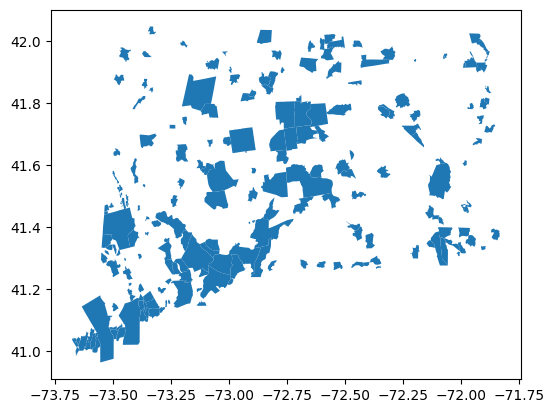

In [151]:
df_CT.plot()

In [143]:
df_CT.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   215 non-null    object  
 1   PLACEFP   215 non-null    object  
 2   PLACENS   215 non-null    object  
 3   GEOID     215 non-null    object  
 4   NAME      215 non-null    object  
 5   NAMELSAD  215 non-null    object  
 6   LSAD      215 non-null    object  
 7   CLASSFP   215 non-null    object  
 8   PCICBSA   215 non-null    object  
 9   PCINECTA  215 non-null    object  
 10  MTFCC     215 non-null    object  
 11  FUNCSTAT  215 non-null    object  
 12  ALAND     215 non-null    int64   
 13  AWATER    215 non-null    int64   
 14  INTPTLAT  215 non-null    object  
 15  INTPTLON  215 non-null    object  
 16  geometry  215 non-null    geometry
dtypes: geometry(1), int64(2), object(14)
memory usage: 28.7+ KB


In [144]:
df_CT.shape

(215, 17)

In [145]:
df_CT = df_CT.rename(columns={'NAME': 'TOWN'})



In [147]:
df = pd.merge(joined_df, df_CT, on='TOWN', how='left')
df
# Left tyring to join the spatial data with the heat pump/demographic data - 4/26 - 12:33 pm

,TOWN,Total Heat Pumps,Median_Household_Income,Tenure_Owner_Occupied(%),Above_National_Average,STATEFP,PLACEFP,PLACENS,GEOID,NAMELSAD,...,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,Andover,95.0,99449.0,88.40,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,Ansonia,115.0,53709.0,59.42,False,09,01150,02378267,0901150,Ansonia city,...,C1,N,N,G4110,A,15588608.0,435200.0,+41.3442494,-073.0698254,"POLYGON ((-73.10219 41.35302, -73.10202 41.353..."
2,Ashford,192.0,84909.0,73.68,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,Avon,445.0,123077.0,83.27,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,Barkhamsted,103.0,103500.0,92.66,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Windsor,393.0,92079.0,82.71,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
135,Wolcott,266.0,96014.0,84.86,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
136,Woodbridge,221.0,169155.0,88.09,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
137,Woodbury,256.0,100850.0,77.77,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [148]:
# geo
import geopandas as gpd

# plotting
from plotnine import *
import plotnine

In [149]:
df.plot